# 8. Diffloop subtype

Part of the **[Fig. 4 chapter](fig4.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
import os
import cooler
import pathlib
import numpy as np
import pandas as pd
from glob import glob
from scipy.sparse import load_npz, save_npz, vstack, csr_matrix, triu
from scipy.stats import f, zscore, ranksums, pearsonr, norm
from schicluster.cool.utilities import get_chrom_offsets
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor, as_completed

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [5]:
from glob import glob

indir = f'{ENTEX_ROOT}/diffloop/majortype-subtype/'
loop_list = np.sort(glob(f'{indir}*_merged_loop.hdf'))
loop_all = {xx.split('/')[-1].split('_')[0]:pd.read_hdf(xx) for xx in loop_list}


In [16]:
loop_all['all'] = pd.read_hdf(f'{ENTEX_ROOT}/analysis/diff_loop/all/merged_loop.hdf')


In [4]:
thres1 = norm.isf(0.025)
thres2 = norm.isf(0.15)
print(thres1, thres2)


1.9599639845400545 1.0364333894937898


In [23]:
fdrthres = 0.05
unique_loop = []
total_loop = []
for ct in loop_all:
    loopall = loop_all[ct]
    loopall.columns = loopall.columns.str.replace('-','')
    loopall = loopall.loc[(loopall['Qanova']>0) & (loopall['Tanova']>0)]
    # print(ct, (loopall['Qanova']==0).sum(), (loopall['Tanova']==0).sum())
    statfilter = (zscore(np.log10(loopall['Qanova']))>thres2) & (zscore(np.log10(loopall['Tanova']))>thres2)
    fdrfilter = (loopall['Qfdr']<fdrthres) & (loopall['Efdr']<fdrthres) & (loopall['Tfdr']<fdrthres)
    selloop = statfilter & fdrfilter
    print(ct, statfilter.sum(), fdrfilter.sum(), selloop.sum())
    unique_loop.append(loopall.loc[selloop].iloc[:, :6])
    total_loop.append(loopall.iloc[:, :6])


c0 81843 306108 81843
c10 89701 46709 46709
c11 19413 11084 11084
c12 29907 21001 18974
c13 39495 8144 8144
c14 41644 33312 33312
c15 15699 278 278
c16 42830 18356 18356
c17 17017 4967 4967
c18 58300 88667 58059
c19 49864 9168 9168
c1 36880 89843 36878
c20 32711 18322 18322
c21 55879 57822 55321
c22 0 0 0
c23 32710 915 915
c24 16132 264 264
c25 0 0 0
c26 10086 3776 3776
c27 13243 2809 2809
c28 28021 104 104
c29 20536 10539 10539
c2 828 2074 815
c30 0 0 0
c31 0 0 0
c32 2954 13 13
c33 15062 0 0
c34 14021 119 119
c3 32901 131932 32901
c4 49321 106245 49308
c5 2126 3990 2123
c6 54536 88709 54523
c7 34665 129413 34661
c8 60935 55007 51606
c9 13640 29926 13633
all 288656 3103539 288656


In [24]:
unique_loop = pd.concat(unique_loop, axis=0).drop_duplicates()
total_loop = pd.concat(total_loop, axis=0).drop_duplicates()


In [25]:
print(unique_loop.shape, total_loop.shape)


(621992, 6) (5387808, 6)


# ANOVA of loop matrices across cell types

In [2]:
group_name = 'EpiBrst'


In [3]:
indir = f'{ENTEX_ROOT}/'
loopdir = f'{indir}loop/subtype/'
outdir = f'{indir}analysis/diff_loop/{group_name}/'


In [4]:
# leg = {'exc': ['L23_IT', 'L4_IT', 'L5_IT', 'L6_IT', 'L6_IT_Car3', 'L56_NP', 'L6_CT', 'L6b', 'Amy'], 
#        'inh': ['Lamp5', 'Lamp5_LHX6', 'Sncg', 'Vip', 'Pvalb', 'Pvalb_ChC', 'Sst', 'CHD7'], 
#        'msn': ['MSN_D1', 'MSN_D2', 'Foxp2'], 
#        'sub': ['SubCtx'], 
#        'glia': ['ASC', 'ODC', 'OPC'], 
#        'mgc': ['MGC'], 
#        'smc': ['PC'], 
#        'endo': ['EC'], 
#        'fibro': ['VLMC'],
#       }
# leg['neu'] = leg['exc'] + leg['inh'] + leg['msn'] + leg['sub']
# leg['all'] = leg['neu'] + leg['glia'] + leg['mgc'] + leg['smc'] + leg['endo'] + leg['fibro']
# L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
# L1_meta = L1_meta.drop(['c35', 'c36'], axis=0)
# L1_annot = L1_meta['L1_abbr'].to_dict()
# L1_color = L1_meta['color'].to_dict()


In [4]:
# ctgroup = []
# if '_' in group_name:
#     for xx in group_name.split('_'):
#         ctgroup.append(leg[xx])
# else:
#     for xx in leg[group_name]:
#         ctgroup.append([xx])
        
leg = pd.Index(['c18-b0', 'c18-b1', 'c25-b0'])
ctgroup = [[xx] for xx in leg]


In [5]:
print(len(ctgroup))

3


In [6]:
# indir = '/home/jzhou_salk_edu/sky_workdir/hba/loop_majortype/'
# outdir = '/home/jzhou_salk_edu/sky_workdir/hba/loop_majortype/'
res = 10000
# group = group_name
L2_meta = pd.read_csv(f'{indir}subtype_meta.tsv', sep='\t', header=0, index_col=0)
L2_annot = L2_meta['celltype_L2_both_abbr'].to_dict()


In [7]:
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]
bins_df = cooler.binnify(chrom_sizes, res)
chrom_offset = get_chrom_offsets(bins_df)


In [8]:
bkl = pd.read_csv(f'{REF_ROOT}/blacklist/hg38_bismark_loop_blacklist.bed', sep='\t', header=None, index_col=None)


In [36]:
result = {'Q':{}, 'E':{}, 'T':{}}
for ct in leg:
    for matrix in 'QET':
        cool_e = cooler.Cooler(f'{loopdir}/{ct}/{ct}.{matrix}.cool')
        n = cool_e.info['group_n_cells']
        result[matrix][ct] = n

pd.DataFrame(result).sum()

Q    2236
E    2236
T    2236
dtype: int64

In [40]:
ncell = pd.Series(result['Q']).sum()
print(ncell)

2236


In [10]:
def compute_anova(c, matrix):
    # c, matrix = args
    ngene = int(chrom_sizes.loc[c] // res) + 1
    bkl_tmp = bkl.loc[(bkl[0]==c), [1,2]].values // res
    cov = np.zeros(ngene)
    for xx,yy in bkl_tmp:
        cov[xx-7:yy+7] = 1
    tot, last = 0, 0
    Esum, E2sum, Elast, E2last, ss_intra = [csr_matrix((ngene, ngene)) for i in range(5)]
    for ctlist in ctgroup:
        for ct in ctlist:
            cool_e = cooler.Cooler(f'{loopdir}{ct}/{ct}.{matrix}.cool')
            E = triu(cool_e.matrix(balance=False, sparse=True).fetch(c))
            cool_e2 = cooler.Cooler(f'{loopdir}/{ct}/{ct}.{matrix}2.cool')
            E2 = triu(cool_e2.matrix(balance=False, sparse=True).fetch(c))
            n = cool_e.info['group_n_cells']
            Esum += E * n
            E2sum += E2 * n
            tot += n
            # print(c, ct)
        Egroup = Esum - Elast
        E2group = E2sum - E2last
        Egroup.data = Egroup.data ** 2 / (tot - last)
        ss_intra += (E2group - Egroup)
        Elast = Esum.copy()
        E2last = E2sum.copy()
        last = tot
    Esum.data = Esum.data ** 2 / tot
    ss_total = E2sum - Esum
    ss_intra.data = 1 / ss_intra.data
    ss_total = ss_total.multiply(ss_intra)
    # print(c, ss_total.data.min(), ss_intra.data.min())

    ss_total.data = (ss_total.data - 1) * (tot - len(ctgroup)) / (len(ctgroup) - 1)
    ss_total = ss_total.tocoo()
    bklfilter = np.logical_and(cov[ss_total.row]==0, cov[ss_total.col]==0)
    distfilter = np.logical_and((ss_total.col-ss_total.row)>5, (ss_total.col-ss_total.row)<500)
    idxfilter = np.logical_and(bklfilter, distfilter)
    # print(idxfilter.sum(), len(idxfilter))
    ss_total = csr_matrix((ss_total.data[idxfilter], (ss_total.row[idxfilter], ss_total.col[idxfilter])), (ngene, ngene))
    save_npz(f'{outdir}subtype_{matrix}pv_{c}.npz', ss_total)

    return [c, matrix, tot]


In [23]:
# for ct in L1_meta.index:
#     for matrix in 'QET':
#         cool_e = cooler.Cooler(f'{loopdir}{ct}/{ct}.{matrix}.cool')
#         n = cool_e.info['group_n_cells']
#         print(ct, matrix, n)
        

In [12]:
cpu = 20
with ProcessPoolExecutor(cpu) as executor:
    futures = []
    for x in chrom_sizes.index:
        for y in 'QET':
            future = executor.submit(
                compute_anova,
                c=x,
                matrix=y,
            )
            futures.append(future)

    # result = []
    for future in as_completed(futures):
        # result.append(future.result())
        # c1, c2 = result[-1][0], result[-1][1]
        tmp = future.result()
        print(f'{tmp[0]} {tmp[1]} finished')
        

chr6 Q finished
chr7 Q finished
chr5 Q finished
chr6 E finished
chr7 E finished
chr5 T finished
chr4 Q finished
chr4 E finished
chr4 T finished
chr3 Q finished
chr3 T finished
chr3 E finished
chr5 E finished
chr2 Q finished
chr2 T finished
chr2 E finished
chr9 Q finished
chr8 Q finished
chr7 T finished
chr9 E finished
chr8 T finished
chr8 E finished
chr9 T finished
chr10 E finished
chr1 E finished
chr10 Q finished
chr10 T finished
chr11 Q finished
chr13 Q finished
chr11 E finished
chr1 T finished
chr12 Q finished
chr6 T finished
chr12 E finished
chr15 Q finished
chr14 Q finished
chr12 T finished
chr16 Q finished
chr17 Q finished
chr15 E finished
chr14 E finished
chr1 Q finished
chr16 T finished
chr14 T finished
chr16 E finished
chr13 E finished
chr17 E finished
chr17 T finished
chr13 T finished
chr19 Q finished
chr19 E finished
chr21 Q finished
chr22 Q finished
chr15 T finished
chr21 T finished
chr20 Q finished
chr19 T finished
chr21 E finished
chr22 T finished
chr18 T finished
chr22 E

In [13]:
def chrom_iterator(input_dir, chrom_order, chrom_offset):
    for chrom in chrom_order:
        output_path = f'{input_dir}_{chrom}.npz'
        if not pathlib.Path(output_path).exists():
            continue
        chunk_size = 5000000
        data = load_npz(output_path).tocoo()
        df = pd.DataFrame({'bin1_id': data.row, 'bin2_id': data.col, 'count': data.data})
        df = df[df['bin1_id'] <= df['bin2_id']]
        for i, chunk_start in enumerate(range(0, df.shape[0], chunk_size)):
            chunk = df.iloc[chunk_start:chunk_start + chunk_size]
            chunk.iloc[:, :2] += chrom_offset[chrom]
            yield chunk


In [14]:
for matrix in 'QET':
    output_path = f'{outdir}subtype_{matrix}pv'
    cooler.create_cooler(cool_uri=f'{output_path}.cool',
                         bins=bins_df,
                         pixels=chrom_iterator(input_dir=output_path,
                                               chrom_order=chrom_sizes.index,
                                               chrom_offset=chrom_offset
                                              ),
                         ordered=True,
                         dtypes={'count': np.float32})


In [15]:
os.system(f'rm {outdir}subtype_*pv_c*.npz')

0

In [9]:
loopall = [pd.read_csv(f'{loopdir}/{ct}/{ct}.loop.bedpe', sep='\t', index_col=None, header=None) for ct in leg]
loopall = pd.concat(loopall, axis=0)
loopall = loopall.drop([6], axis=1).drop_duplicates(subset=[0,1,4]).sort_values([0,1,4])
loopall = pd.concat([loopall[(loopall[0]==c).values] for c in chrom_sizes.index])
loopall.index = np.arange(loopall.shape[0])
loopall


,0,1,2,3,4,5
0,chr1,900000,910000,chr1,960000,970000
1,chr1,900000,910000,chr1,970000,980000
2,chr1,910000,920000,chr1,970000,980000
3,chr1,960000,970000,chr1,1270000,1280000
4,chr1,960000,970000,chr1,1280000,1290000
...,...,...,...,...,...,...
1110030,chr22,50530000,50540000,chr22,50610000,50620000
1110031,chr22,50530000,50540000,chr22,50620000,50630000
1110032,chr22,50540000,50550000,chr22,50600000,50610000
1110033,chr22,50540000,50550000,chr22,50610000,50620000


In [10]:
loopall.to_csv(f'{outdir}merged_loop.bedpe', sep='\t', index=False, header=False)
loopall.to_hdf(f'{outdir}merged_loop.hdf', key='data')


In [11]:
for c in chrom_sizes.index:
    loopfilter = (loopall[0]==c)
    looptmp = loopall.loc[loopfilter, [1,4]].values // res
    for matrix in 'QET':
        cool = cooler.Cooler(f'{outdir}subtype_{matrix}pv.cool')
        pv = triu(cool.matrix(balance=False, sparse=True).fetch(c)).tocsr()
        loopall.loc[loopfilter, f'{matrix}anova'] = pv[(looptmp[:,0], looptmp[:,1])].A1
    print(c)


chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
chr21
chr22


In [41]:
from scipy.stats import f
from statsmodels.sandbox.stats.multicomp import multipletests as FDR
    
def stats2fdr(data):
    pv = [f.sf(x, nct-1, ncell-nct) for x in data.values]
    fdr = FDR(pv, 0.01, "fdr_bh")[1]
    return fdr


In [47]:
nct = len(leg)
print(ncell, nct)

2236 3


In [44]:
cpu = 3
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for m in 'QET':
        future = executor.submit(
            stats2fdr,
            loopall[f'{m}anova']
        )
        futures[future] = m

    # result = []
    for future in as_completed(futures):
        m = futures[future]
        loopall[f'{m}fdr'] = future.result()
        print(f'{m} finished')
        

E finished
T finished
Q finished


In [46]:
loopall.to_hdf(f'{outdir}merged_loop.hdf', key='data')


## Load Loop Q

In [20]:
loopall = pd.read_hdf(f'{outdir}merged_loop.hdf', key='data')
loopall

,0,1,2,3,4,5,Qanova,Eanova,Tanova
0,chr1,960000,970000,chr1,1280000,1290000,3.344096,9.765030,1.294619
1,chr1,960000,970000,chr1,1290000,1300000,0.294751,6.269100,0.366250
2,chr1,960000,970000,chr1,1300000,1310000,0.233432,3.334288,0.901931
3,chr1,970000,980000,chr1,1250000,1260000,1.606292,10.676738,0.956993
4,chr1,970000,980000,chr1,1270000,1280000,2.295421,9.133983,0.307463
...,...,...,...,...,...,...,...,...,...
854022,chr22,50530000,50540000,chr22,50610000,50620000,12.249915,18.597105,6.991621
854023,chr22,50530000,50540000,chr22,50620000,50630000,9.747795,18.063080,6.300688
854024,chr22,50540000,50550000,chr22,50600000,50610000,4.138350,9.628341,1.233643
854025,chr22,50540000,50550000,chr22,50610000,50620000,5.581578,10.344213,1.510063


In [13]:
def load_Q(ct, m):
    tmp = []
    cool_file = cooler.Cooler(f'{loopdir}{ct}/{ct}.{m}.cool').matrix(balance=False, sparse=True)
    for c in chrom_sizes.index:
        mat = cool_file.fetch(c).tocsr()
        tmp.append(mat[(loopall.loc[loopall[0]==c, 1].values // res, loopall.loc[loopall[0]==c, 4].values // res)].A1)
        # print(ct, c)
    return [ct, np.concatenate(tmp)]


In [14]:
cpu = 20
with ProcessPoolExecutor(cpu) as executor:
    futures = []
    for xx in leg:
        future = executor.submit(
            load_Q,
            ct=xx,
            m='Q'
        )
        futures.append(future)

    loopq = []
    for future in as_completed(futures):
        tmp = future.result()
        loopq.append(pd.DataFrame(tmp[1], columns=[tmp[0]]))
        print(f'{tmp[0]} finished')
        

c25-b0 finished
c18-b1 finished
c18-b0 finished


In [15]:
loopq = pd.concat(loopq, axis=1)
loopq = loopq[leg]


In [16]:
loopq.to_hdf(f'{outdir}loop_Q.hdf', key='data')


In [17]:
cpu = 20
with ProcessPoolExecutor(cpu) as executor:
    futures = []
    for xx in leg:
        future = executor.submit(
            load_Q,
            ct=xx,
            m='T'
        )
        futures.append(future)

    loopt = []
    for future in as_completed(futures):
        tmp = future.result()
        loopt.append(pd.DataFrame(tmp[1], columns=[tmp[0]]))
        print(f'{tmp[0]} finished')
        

c18-b0 finished
c25-b0 finished
c18-b1 finished


In [18]:
loopt = pd.concat(loopt, axis=1)
loopt = loopt[leg]


In [19]:
loopt.to_hdf(f'{outdir}loop_T.hdf', key='data')


In [20]:
print(loopall.shape, loopq.shape, loopt.shape)

(1110035, 9) (1110035, 3) (1110035, 3)


In [57]:
loopq = pd.read_hdf(f'{outdir}loop_Q.hdf', key='data')
loopt = pd.read_hdf(f'{outdir}loop_T.hdf', key='data')


In [21]:
sell = (loopall['Qanova']==0) | (loopall['Eanova']==0) | (loopall['Tanova']==0)
print(sell.sum())


0


In [59]:
# loopall = loopall.loc[~sell]
# loopq = loopq.loc[~sell]
# loopt = loopt.loc[~sell]


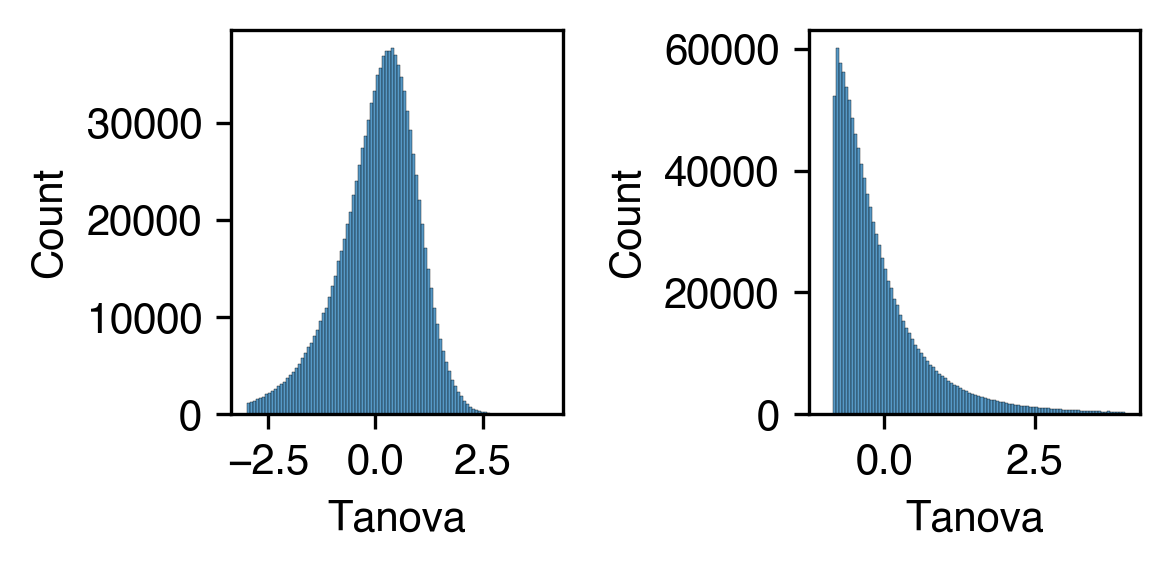

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2), dpi=300)
ax = axes[0]
sns.histplot(zscore(np.log10(loopall['Tanova'])), bins=100, binrange=(-3,4), ax=ax)
ax = axes[1]
sns.histplot(zscore(loopall['Tanova']), bins=100, binrange=(-1,4), ax=ax)
plt.tight_layout()


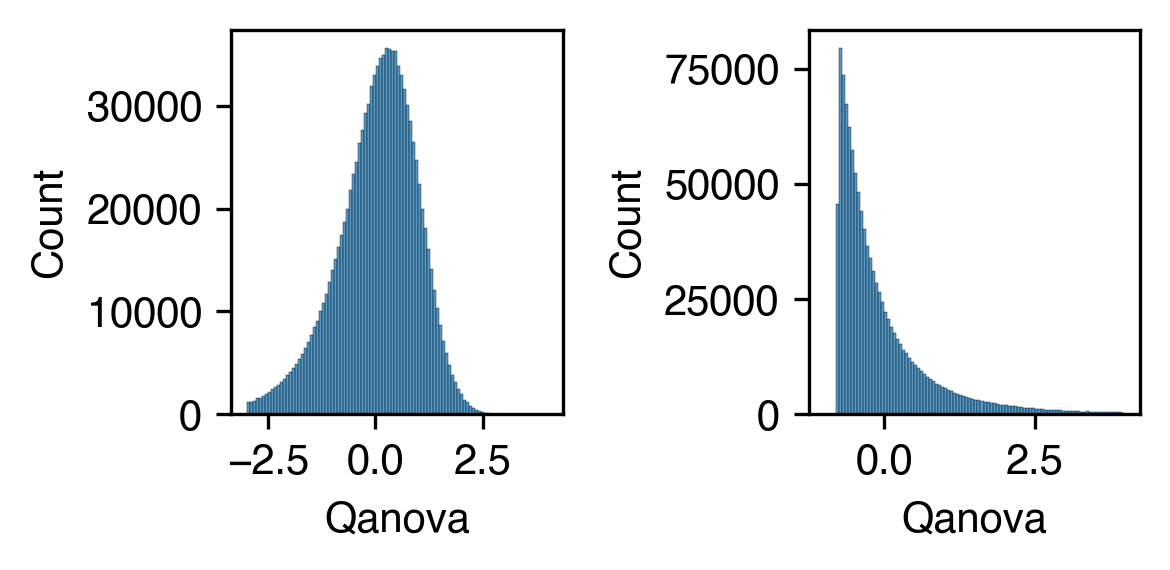

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2), dpi=300)
ax = axes[0]
sns.histplot(zscore(np.log10(loopall['Qanova'])), bins=100, binrange=(-3,4), ax=ax)
ax = axes[1]
sns.histplot(zscore(loopall['Qanova']), bins=100, binrange=(-1,4), ax=ax)
plt.tight_layout()


In [60]:
outdir

'/large_storage/zhoulab/zhoujt/project/ENTEx/analysis/diff_loop/EpiBrst/'

In [24]:
thres1 = norm.isf(0.025)
thres2 = norm.isf(0.15)
print(thres1, thres2)


1.9599639845400545 1.0364333894937898


In [25]:
# selb = ((zscore(loopall['Qanova'])>thres2) & (zscore(loopall['Tanova'])>thres2))
# print(selb.sum())
selb = ((zscore(np.log10(loopall['Qanova']))>thres2) & (zscore(np.log10(loopall['Tanova']))>thres2))
print(selb.sum())


70949


In [53]:
fdrthres = 0.01
statfilter = (zscore(np.log10(loopall['Qanova']))>thres2) & (zscore(np.log10(loopall['Tanova']))>thres2)
fdrfilter = (loopall['Qfdr']<fdrthres) & (loopall['Efdr']<fdrthres) & (loopall['Tfdr']<fdrthres)
selloop = statfilter & fdrfilter
print(statfilter.sum(), fdrfilter.sum(), selloop.sum())


70949 103048 70655


In [54]:
tmpq = loopq.loc[selloop].values
tmpq = zscore(tmpq, axis=1)


In [55]:
tmpt = loopt.loc[selloop].values
tmpt = zscore(tmpt, axis=1)


In [56]:
np.random.seed(0)
sel = np.random.choice(np.arange(len(tmpq)), 2000, False)


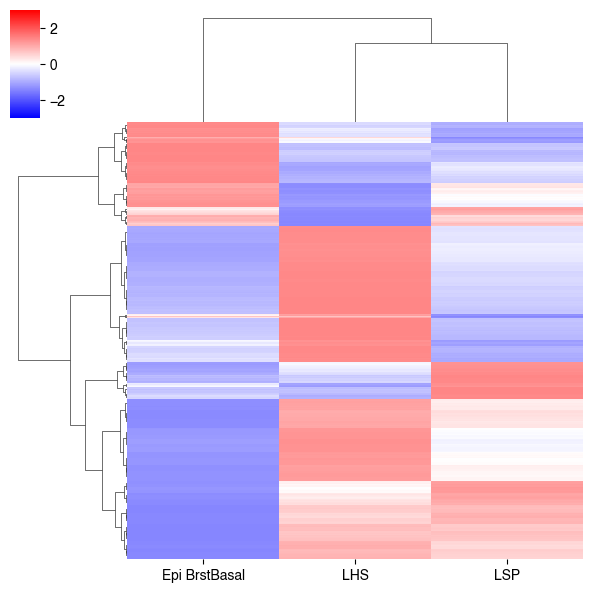

In [57]:
cg = sns.clustermap(tmpq[sel], cmap='bwr', vmin=-3, vmax=3, method='ward', # metric='cosine', 
                    xticklabels=leg.map(L2_annot), yticklabels=[], figsize=(6,6))


In [58]:
rorder = cg.dendrogram_row.reordered_ind.copy()
corder = cg.dendrogram_col.reordered_ind.copy()

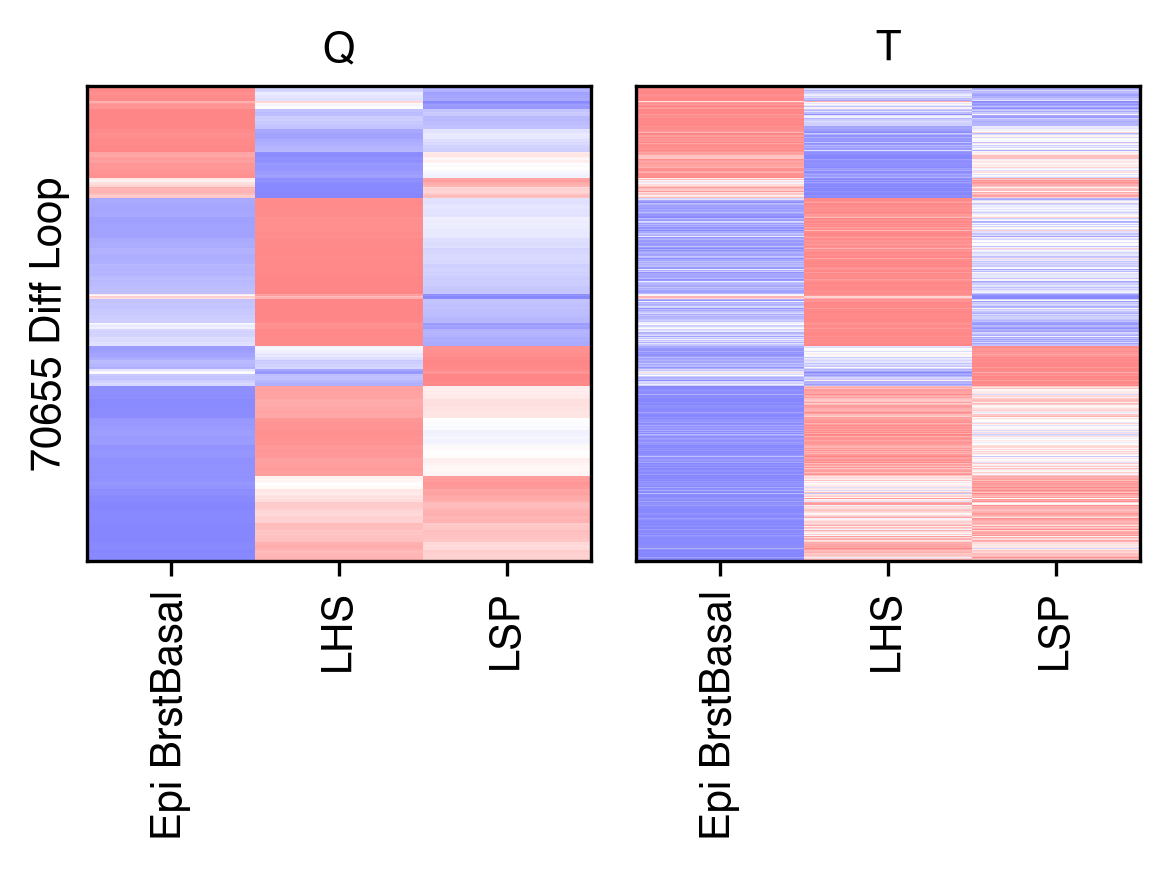

In [59]:
fig, axes = plt.subplots(1, 2, sharey='all', figsize=(4, 3), dpi=300)

ax = axes[0]
ax.imshow(tmpq[np.ix_(sel[rorder], corder)], cmap='bwr', aspect='auto', vmin=-3, vmax=3, interpolation='none')
ax.set_title('Q', fontsize=10)
# sns.despine(ax=ax, left=True, bottom=True)
ax.set_xticks(np.arange(len(leg)))
ax.set_xticklabels(leg[corder].map(L2_annot), rotation=90)
ax.set_yticks([])
ax.set_ylabel(f'{tmpq.shape[0]} Diff Loop')

ax = axes[1]
ax.imshow(tmpt[np.ix_(sel[rorder], corder)], cmap='bwr', aspect='auto', vmin=-3, vmax=3, interpolation='none')
ax.set_title('T', fontsize=10)
# sns.despine(ax=ax, left=True, bottom=True)
ax.set_xticks(np.arange(len(leg)))
ax.set_xticklabels(leg[corder].map(L2_annot), rotation=90)

plt.tight_layout()
